In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [9]:
df = pd.read_csv(r"C:\Users\ramad\OneDrive\文档\Desktop\siri project\assests\WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize = True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


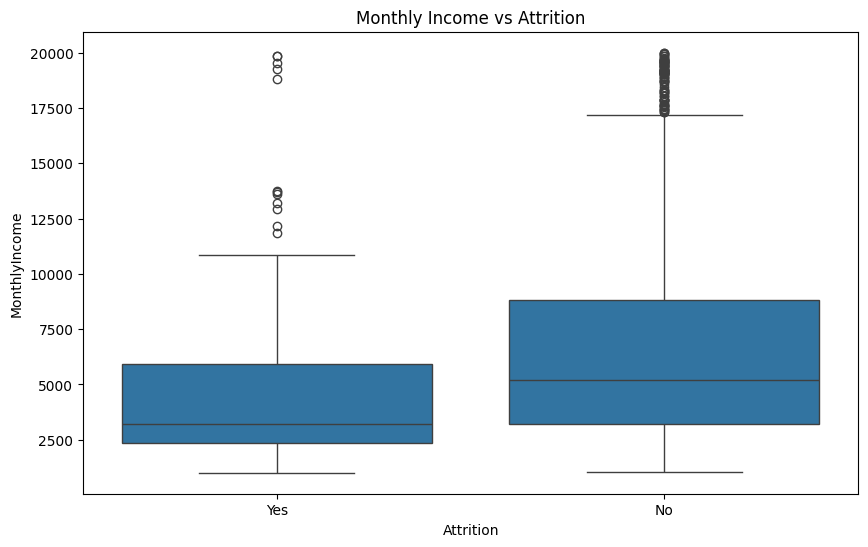

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition" ,y="MonthlyIncome",data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

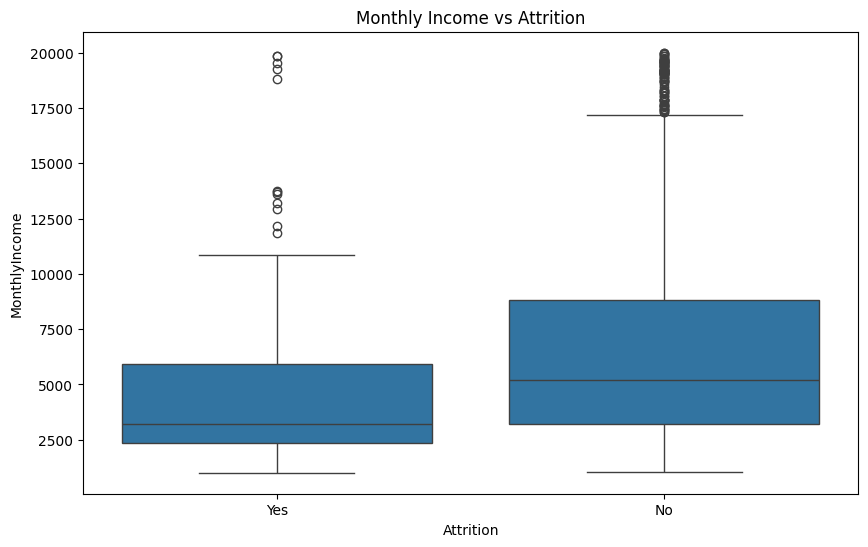

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition" ,y="MonthlyIncome",data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

In [12]:
encoders={}
for col in df.select_dtypes(include=["object"]).columns:
    lb = LabelEncoder()
    df[col] = lb.fit_transform(df[col])
    encoders[col]=lb

x = df.drop("Attrition",axis =1)
y = df["Attrition"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [ 10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
Grid_search = GridSearchCV(rf, param_grid = param_grid, cv=5, scoring="f1")
Grid_search.fit(x_train, y_train)
print("Best Parameters:", Grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


In [14]:
best_model = Grid_search.best_estimator_
predictions = best_model.predict(x_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294

[[255   0]
 [ 35   4]]


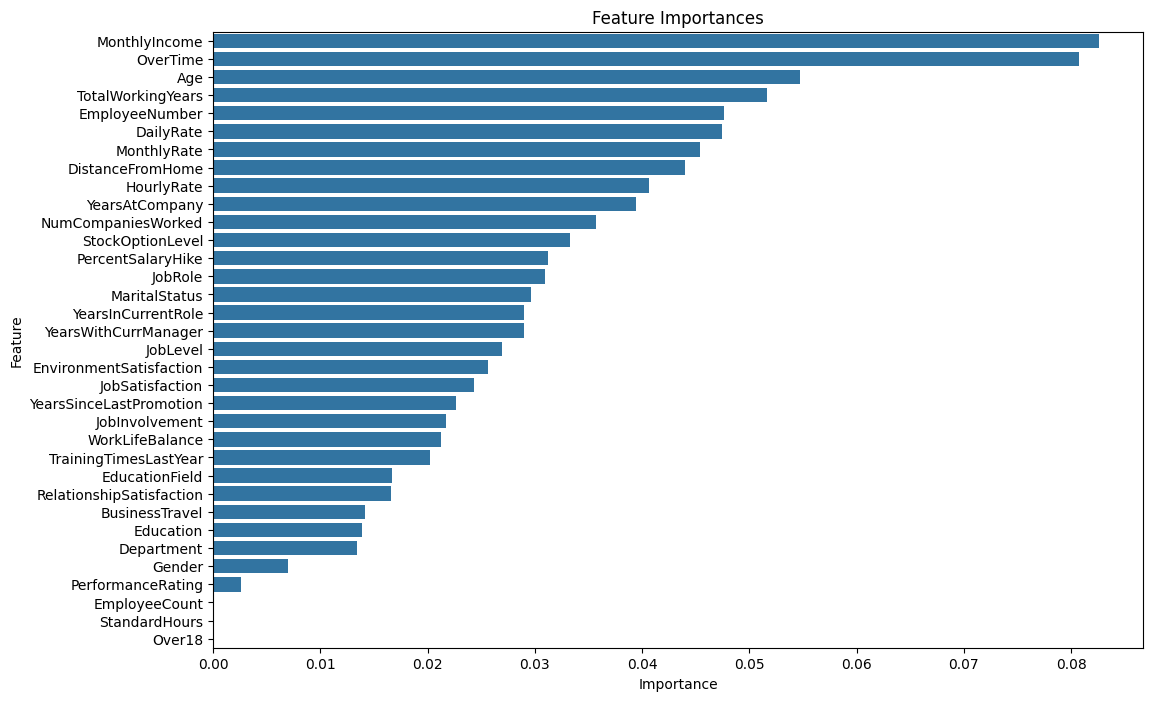

In [15]:
importances = pd.DataFrame({
    "Feature": x.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(12,8))
sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Feature Importances")
plt.show()

In [16]:
model = RandomForestClassifier(n_estimators=50, max_depth=20, min_samples_split=5, min_samples_leaf=2, random_state=42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [17]:
joblib.dump(model, "attrition_model.pkl")
joblib.dump(lb, "label_encoder.pkl")
joblib.dump(importances, "feature_columns.pkl")

['feature_columns.pkl']